In [1]:
from collections import Counter

import pandas as pd
from wordcloud import WordCloud, STOPWORDS
import matplotlib.pyplot as plt
from IPython.display import Markdown
from ipywidgets import HTML
from ipyleaflet import Map, Marker, MarkerCluster, Popup

In [2]:
fname = "PyCampAna 2025 (Responses) - Form Responses 1.csv"
df = pd.read_csv(fname)

coords_fname = "cities_coords.csv"
coords_df = pd.read_csv(coords_fname, index_col="Unnamed: 0")

In [3]:
def word_c(col_name, replacements={}, exclude=[], show_counter=False):
    col = df[col_name].fillna("").str.strip().str.lower()
    if replacements:
        for k,v in replacements.items():
            col = col.str.replace(k,v)
    show_counter and print(col.value_counts())
    words_count = Counter(map(str.strip, (col.str.cat(sep=",").split(","))))
    all_words = col.str.cat(sep=" ")
    stopwords = STOPWORDS.union(["de", "el", "del", "la", "en", "las", "que", "y", "muy", "un"])
    wordcloud = WordCloud(width = 720, height = 720,
                background_color ='white',
                stopwords = stopwords.union(exclude),
                min_font_size = 10).generate(all_words)

    # plot the WordCloud image                      
    plt.figure(figsize = (8, 8), facecolor = None)
    plt.imshow(wordcloud)
    plt.axis("off")
    plt.tight_layout(pad = 0)

    plt.show()

In [4]:
def add_coords(df, coords_df, replacements={}):
    df = df.copy()
    df["city"] = df["¿De dónde venís? (por lo menos ciudad + provincia)"].str.lower().str.strip().replace(replacements)
    df_full = df.merge(coords_df, on="city", how="left")
    return df_full

# ¿De dónde vinieron?

---

In [ ]:
from geopy.geocoders import Nominatim

geolocator = Nominatim(timeout=10, user_agent="PyCampana Report 2025")

locations = {}

In [ ]:
# HACK: Si hay timeouts, repetir
for location in set(...):
    if location not in locations:
        locations[location] = geolocator.geocode(location.strip())

In [ ]:
coords_df_extra = pd.DataFrame([
    {
    "city": key.strip().lower(),
    "lats": loc.latitude,
    "lngs": loc.longitude,
    "size": 1
    }
    for key, loc in locations.items()
    if loc is not None
])

coords_df_new = pd.concat([coords_df, coords_df_extra]).drop_duplicates(subset="city")
coords_df_new.reset_index(drop=True).to_csv(coords_fname)

---

In [5]:
df_full = add_coords(df, coords_df, replacements={
    "caba": "CABA",
    "bs.as.": "CABA",
    "ciudad autonoma de buenos aires": "CABA",
    "ciudad autónoma de buenos aires": "CABA",
    "capital federal": "CABA",
    "capital federal caba": "CABA",
    "buenos aires": "CABA",
    "Capital federal bs as": "CABA",
    "ciudad de buenos aires": "CABA",
    "caba, buenos aires": "CABA",
    "caba ,almagro": "almagro, buenos aires",
    "buenos aires, vicente lopez": "vicente lópez, buenos aires",
    "vicente lópez,bsas": "vicente lópez, buenos aires",
    "vicente lopez, bs as": "vicente lópez, buenos aires",
    "vicente lópez, provincia de buenos aires": "vicente lópez, buenos aires",
    "quilmes": "quilmes, buenos aires",
    "recoleta": "recoleta, buenos aires",
    "lanus buenos aires": "lanus, buenos aires",
    "buenos aires, buenos airez": "CABA",
    "boedo, ciudad autónoma de buenos aires, argentina": "boedo, buenos aires",
    "san telmo": "san telmo, buenos aires",
    "villa pueyrredón, caba": "villa pueyrredón, buenos aires",
    "caba, palermo": "palermo, buenos aires",
    "la plata. buenos aires": "la plata, buenos aires",
    "cordoba": "córdoba",
    "santa fe, rafaela": "rafaela, santa fe",
    "rafaela santa fe": "rafaela, santa fe",
    "rafaela": "rafaela, santa fe",
    "rosario": "rosario, santa fe",
    "paraná": "paraná, entre ríos",
})

In [6]:
m = Map(center=(-34.607568, -58.437089), zoom=4)

markers = []
for _, row in df_full.dropna(subset=["lats", "lngs"]).iterrows():
    marker = Marker(location=(row["lats"], row["lngs"]))

    message = HTML()
    message.value = row["¿De dónde venís? (por lo menos ciudad + provincia)"]
    marker.popup = message

    markers.append(marker)

marker_cluster = MarkerCluster(markers=markers, max_cluster_radius=20)

m.add(marker_cluster);
m

Map(center=[-34.607568, -58.437089], controls=(ZoomControl(options=['position', 'zoom_in_text', 'zoom_in_title…

# Promedios

In [7]:
Markdown(f"""* ¿Cuántos kilómetros hiciste para llegar?	**{df["¿Cuántos kilómetros hiciste para llegar?"].mean().round(-1)}** (808.83)
* ¿Cuántas veces te bañaste?	**{df["¿Cuántas veces te bañaste?"].median()}** (3.52)
* ¿A cuántos PyCamp fuiste? (contando el actual)?	**{df["¿A cuántos PyCamp fuiste? (contando el actual)?"].median()}** (3.38)
* ¿En cuántos proyectos participaste en este PyCamp?	**{df["¿En cuántos proyectos participaste en este PyCamp?"].median()}** (2.1)
* ¿Qué nota le pondrías a la comida?	**{df["¿Qué nota le pondrías a la comida?"].mean()}** (8.6)
* ¿Qué nota le pondrías a los dormitorios?	**5.95** (7.25)
* ¿Qué nota le pondrías a Internet?	**{df["¿Qué nota le pondrías a Internet?"].mean()}** (4.12)
* ¿Qué nota le pondrías al lugar?	**{df["¿Qué nota le pondrías al lugar?"].mean()}** (8.45)
* Tu edad	**{df["Tu edad"].mean()}** (32)
* ¿Tenés hijes?	**{(df["¿Tenés hijes?"].value_counts(normalize=True).loc[0] * 100).round(1)} %** no tiene, el resto tiene **{df.loc[(df["¿Tenés hijes?"] != 0) & (df["¿Tenés hijes?"].notna()), "¿Tenés hijes?"].mean().round(1)}** hijes de media (0.45)
""")

* ¿Cuántos kilómetros hiciste para llegar?	**950.0** (808.83)
* ¿Cuántas veces te bañaste?	**3.5** (3.52)
* ¿A cuántos PyCamp fuiste? (contando el actual)?	**2.0** (3.38)
* ¿En cuántos proyectos participaste en este PyCamp?	**2.0** (2.1)
* ¿Qué nota le pondrías a la comida?	**8.35** (8.6)
* ¿Qué nota le pondrías a los dormitorios?	**5.95** (7.25)
* ¿Qué nota le pondrías a Internet?	**4.425** (4.12)
* ¿Qué nota le pondrías al lugar?	**7.875** (8.45)
* Tu edad	**32.95** (32)
* ¿Tenés hijes?	**82.1 %** no tiene, el resto tiene **1.7** hijes de media (0.45)


# Dónde debería ser el próximo PyCamp

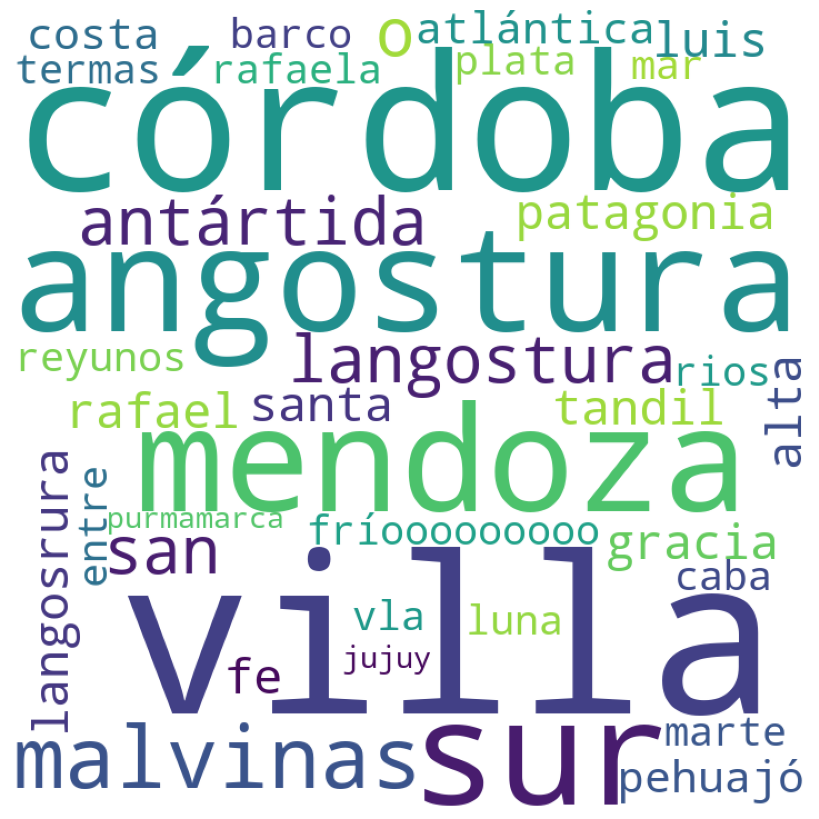

In [8]:
word_c(
    '¿Dónde te gustaría que se haga un PyCamp?', 
   replacements={'cordoba': "córdoba", 'jesús mario': "jesus maria"}
)

# Nivel de manejo de Python de los PyCampistas

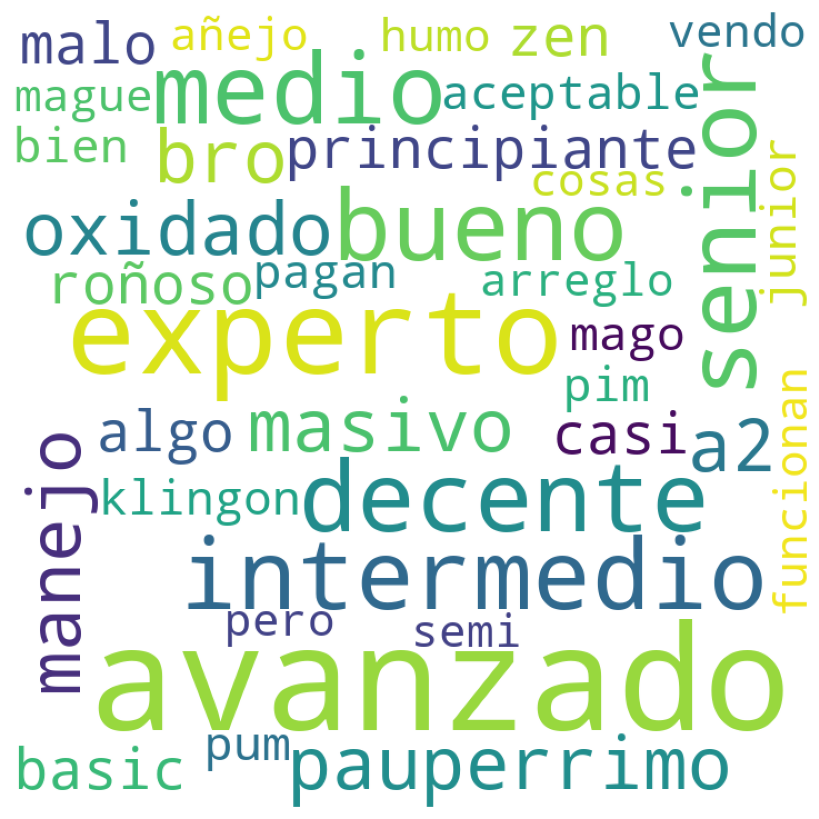

In [9]:
word_c(
    '¿Cómo describirías tu nivel de manejo de Python?', 
    replacements={"basico":"básico", "avanzaso":"avanzado"}, 
    exclude=["si", "sin", "al", ]
)

# Feedback

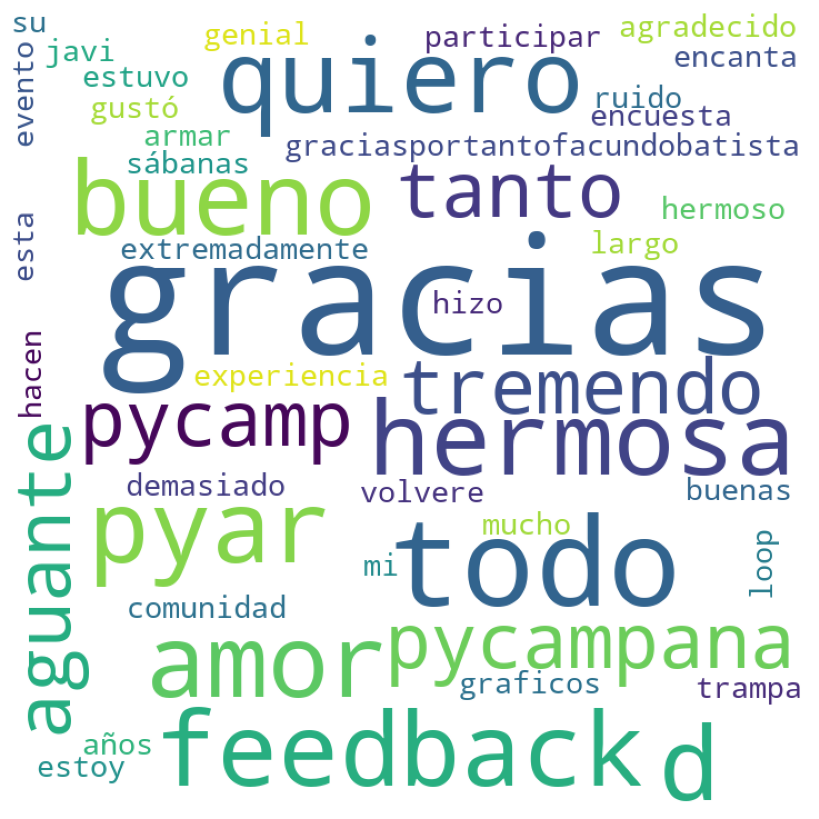

In [10]:
word_c(
    "¿Querés dejar algún otro feedback?",
    replacements={"ek":"el"},
    exclude=["son", "así", "otra", "lo", "pre", "mas", "se", "es", "les", "por", "si", "los", "las", "para", "ya", "con"]
)

# Místico

# ¿Cuánto se bañan por cada signo?

In [11]:
Markdown(
    "\n".join(
        f"* {signo} **{freq}**"
        for signo, freq
        in df.groupby("¿Cuál es tu signo del zodíaco?")["¿Cuántas veces te bañaste?"].median().sort_values(ascending=False).items()
    )
)

* Escorpión **4.5**
* Cáncer **4.0**
* Piscis **4.0**
* Virgo **3.5**
* Aries **3.0**
* Géminis **3.0**
* Leo **3.0**
* Libra **3.0**
* Sagitario **3.0**
* Tauro **3.0**
* Acuario **2.5**

* Fuerte influencia de *Tauro* en la comunidad
* Hay que trabajar en términos de inclusión (astral) para aumentar el federalismo astral de Aries y Leo
* Los de Tauro y los Leo usan mucho Python en el laburo, pero los de Piscis poco
* Los Gallos (en el Chino) podrían revisar sus desiciones higiénicas, ahora los Rata podrían ahorrar agua
* Tigres y Mono programando mucho Python (atenti para recruiting)